C:\Users\nitin bansal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster Labels:
[1 1 1 0 0 0 0 1 1 0 0 1 1 0 0]

Final Data with Clusters:
    StudyHours  SleepHours  Cluster
0            2           5        1
1            3           6        1
2            4           5        1
3            5           7        0
4            6           8        0
5            7           7        0
6            8           9        0
7            1           4        1
8            2           6        1
9            9           8        0
10          10           9        0
11           1           3        1
12           3           5        1
13           6           7        0
14           8           8        0

Silhouette Score: 0.6103819264582196


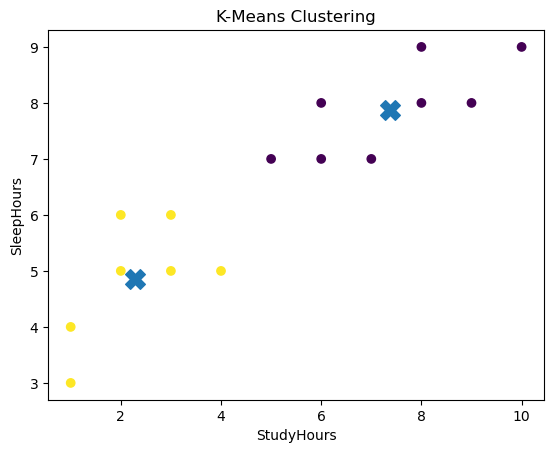

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("KM2.csv")
X = data.values

# Apply K-Means
kmeans = KMeans(n_clusters=2, random_state=4)
labels = kmeans.fit_predict(X)

# Add cluster labels to dataset
data['Cluster'] = labels

# Print results
print("Cluster Labels:")
print(labels)

print("\nFinal Data with Clusters:")
print(data)

# Evaluate clustering
score = silhouette_score(X, labels)
print("\nSilhouette Score:", score)

# ----------------------------
# Visualization
# ----------------------------
plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            marker='X', s=200)

plt.title("K-Means Clustering")
plt.xlabel("StudyHours")
plt.ylabel("SleepHours")
plt.show()

C:\Users\nitin bansal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\nitin bansal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K-Means Silhouette Score: 0.5019587147915919
GMM (EM) Silhouette Score: 0.5019587147915919


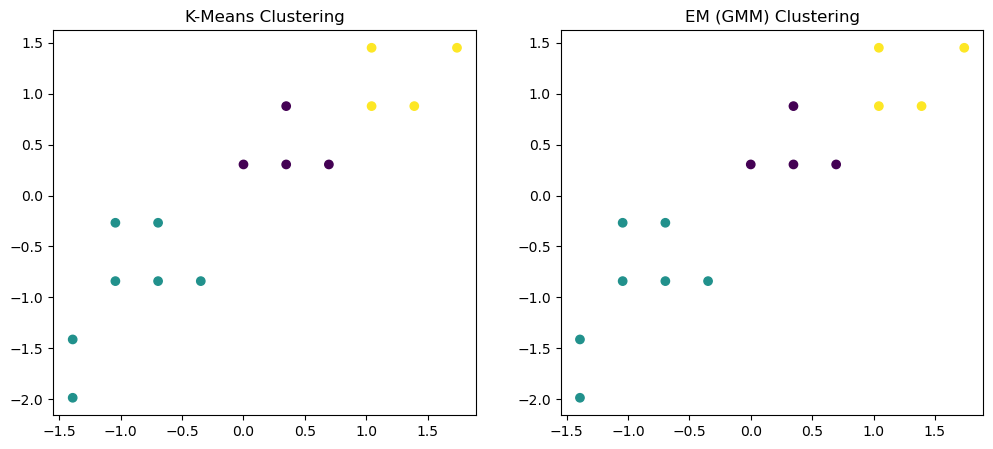

In [2]:
#Both EM & K-Means
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Load Dataset
df = pd.read_csv('KM2.csv')

# 2. Select numeric columns only
X = df.select_dtypes(include=[np.number])

# 3. Handle missing values (if any)
X = X.dropna()

# 4. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# K-MEANS CLUSTERING
# -------------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# -------------------------------
# EM (Gaussian Mixture Model)
# -------------------------------
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# -------------------------------
# Evaluation using Silhouette Score
# -------------------------------
kmeans_score = silhouette_score(X_scaled, kmeans_labels)
gmm_score = silhouette_score(X_scaled, gmm_labels)

print("K-Means Silhouette Score:", kmeans_score)
print("GMM (EM) Silhouette Score:", gmm_score)

# -------------------------------
# Visualization (first 2 features)
# -------------------------------
plt.figure(figsize=(12,5))

# K-Means Plot
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")

# GMM Plot
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=gmm_labels, cmap='viridis')
plt.title("EM (GMM) Clustering")

plt.show()